We use the functions we defined in the regression_utils file. This notebook is just for running and plotting them.

In [74]:
import pandas as pd
from regression_utils import *

In [75]:
session = 757216464

In [76]:
drifting_dataset = pd.read_parquet(f'../ourdata/drifting_dataset_session_{session}.parquet')
static_dataset = pd.read_parquet(f'../ourdata/static_dataset_session_{session}.parquet')

We restrict our attention to those visual areas which have a high number of neurons with high variance:

In [77]:
high_variance_visual_areas = ['VISal', 'VISp', 'VISrl', 'VISam', 'VISl']

In [78]:
def area_summary_df(area, plot=False):
    temporal_frequency = summarise_area(drifting_dataset, area, 'temporal_frequency', plot=plot)
    orientation_drifting = summarise_area(drifting_dataset, area, 'orientation', plot=plot)
    spatial_frequency = summarise_area(static_dataset, area, 'spatial_frequency', plot=plot)
    orientation_static = summarise_area(static_dataset, area, 'orientation', plot=plot)
    return pd.DataFrame({
        'temporal_frequency': temporal_frequency,
        'orientation_drifting': orientation_drifting,
        'spatial_frequency': spatial_frequency,
        'orientation_static': orientation_static
    }).T

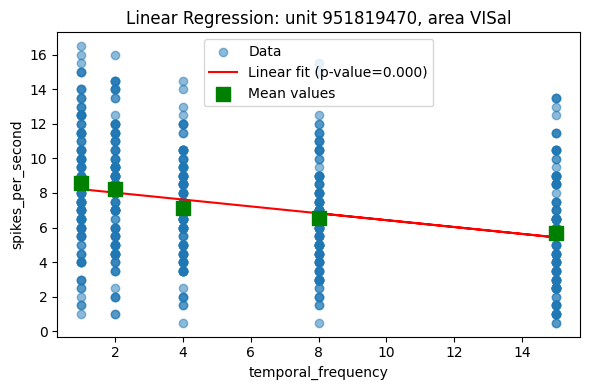

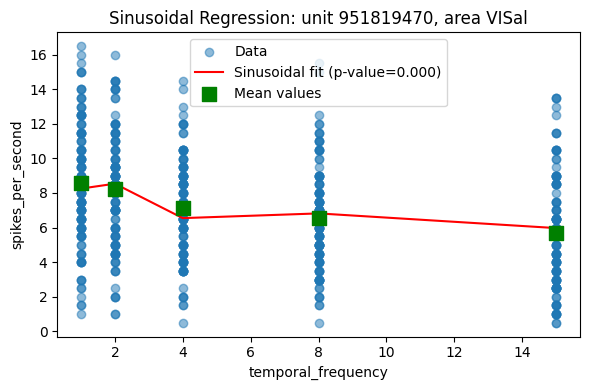

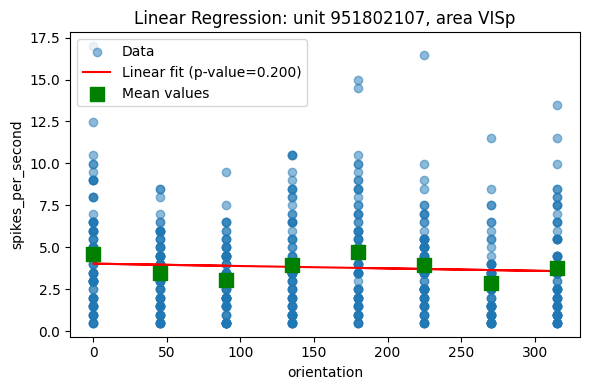

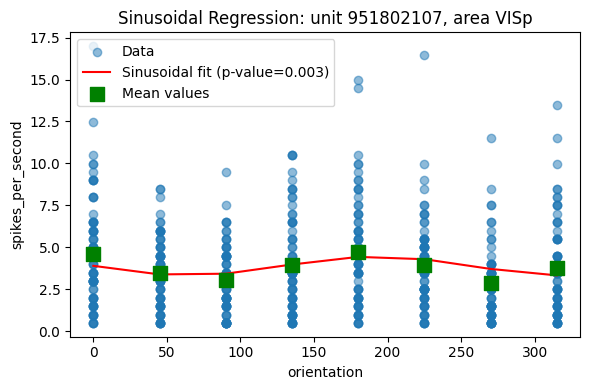

{'linear_r2': 0.0028839283714990893,
 'linear_p_value': 0.20046343552447676,
 'slope': -0.0014122829821001394,
 'slope_direction': 'negative',
 'sin_r2': 0.020577422844353044,
 'sin_p_value': 0.002754396450931784}

In [ ]:
# plot some example units:
unit_951819470 = drifting_dataset[drifting_dataset['unit_id'] == 951819470][['unit_id', 'temporal_frequency', 'orientation', 'spikes_per_second']]
unit_951802107 = drifting_dataset[drifting_dataset['unit_id'] == 951802107][['unit_id', 'temporal_frequency', 'orientation', 'spikes_per_second']]

fit_and_test_models(unit_951819470['temporal_frequency'].values, unit_951819470['spikes_per_second'].values, '951819470', 'VISal', 'temporal_frequency', plot=True)
fit_and_test_models(unit_951802107['orientation'].values, unit_951802107['spikes_per_second'].values, '951802107', 'VISp', 'orientation', plot=True)

In [81]:
area_summary_df('VISal')

,n_units,n_linear_significant,n_positive,n_negative,n_sin_significant
temporal_frequency,53,43,18,25,45
orientation_drifting,53,21,8,13,34
spatial_frequency,53,35,5,30,37
orientation_static,53,30,18,12,37


In [82]:
area_summary_df('VISp')

,n_units,n_linear_significant,n_positive,n_negative,n_sin_significant
temporal_frequency,85,60,17,43,64
orientation_drifting,85,26,8,18,59
spatial_frequency,85,56,16,40,63
orientation_static,85,47,23,24,62


In [83]:
area_summary_df('VISrl')

,n_units,n_linear_significant,n_positive,n_negative,n_sin_significant
temporal_frequency,37,19,9,10,23
orientation_drifting,37,17,9,8,19
spatial_frequency,37,20,8,12,24
orientation_static,37,18,10,8,19


In [84]:
area_summary_df('VISam')

,n_units,n_linear_significant,n_positive,n_negative,n_sin_significant
temporal_frequency,64,40,18,22,43
orientation_drifting,64,22,8,14,32
spatial_frequency,64,41,12,29,43
orientation_static,64,31,22,9,39


In [85]:
area_summary_df('VISl')

,n_units,n_linear_significant,n_positive,n_negative,n_sin_significant
temporal_frequency,53,34,9,25,35
orientation_drifting,53,21,1,20,33
spatial_frequency,53,35,14,21,43
orientation_static,53,31,11,20,37


In [86]:
    if plot:
        # Calculate mean y for each unique x value
        df = pd.DataFrame({'x': X, 'y': y})
        means = df.groupby('x')['y'].mean().reset_index()
        
        # Plot linear fit
        plt.figure(figsize=(6, 4))
        plt.scatter(X, y, alpha=0.5, label='Data')
        plt.plot(X, y_pred_linear, color='red', label=f'Linear fit (p-value={p_value_linear:.3f})')
        plt.scatter(means['x'], means['y'], color='green', s=100, marker='s', 
                   label='Mean values', zorder=3)
        plt.xlabel(f'{covariate}')
        plt.ylabel('spikes_per_second')
        plt.title(f'Linear Regression: unit {unit_id}, area {area}')
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        # Plot sinusoidal fit
        plt.figure(figsize=(6, 4))
        plt.scatter(X, y, alpha=0.5, label='Data')
        sort_idx = np.argsort(X)
        plt.plot(X[sort_idx], y_pred_sin[sort_idx], color='red', 
                 label=f'Sinusoidal fit (p-value={p_value_sin:.3f})')
        plt.scatter(means['x'], means['y'], color='green', s=100, marker='s', 
                   label='Mean values', zorder=3)
        plt.xlabel(f'{covariate}')
        plt.ylabel('spikes_per_second')
        plt.title(f'Sinusoidal Regression: unit {unit_id}, area {area}')
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    return {
        'linear_r2': r2_linear,
        'linear_p_value': p_value_linear,
        'slope': slope,
        'slope_direction': 'positive' if slope > 0 else 'negative',
        'sin_r2': r2_sin,
        'sin_p_value': p_value_sin
    }

NameError: name 'plot' is not defined